# LeetCode #5: Longest Palindromic Substring

https://leetcode.com/problems/longest-palindromic-substring/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(n^3)$ | $O(1)$ |
| **Dynamic Programming** | $O(n^2)$ | $O(n^2)$ |
| **Expand Around Center** ★ | $O(n^2)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force
Generate every possible substring ($O(n^2)$ pairs) and check if each is a palindrome ($O(n)$ per check). Triples the time to $O(n^3)$ — impractical for large strings.

### Dynamic Programming
Build a 2D boolean table where `dp[i][j]` is true if `s[i..j]` is a palindrome. Fill it diagonally from length 1 upward. Matches Expand Around Center on time but needs $O(n^2)$ extra space for the table.

### Optimal: Expand Around Center ★
A palindrome mirrors around its center. There are $2n-1$ centers (each character and each gap between characters). Expand outward from each center while characters match, tracking the longest found.

**Why this is better than Dynamic Programming:** Both run in $O(n^2)$ time, but Expand Around Center uses $O(1)$ space — no table allocation — making it strictly better for large inputs.

**Note:** Manacher's Algorithm achieves $O(n)$ time and $O(n)$ space but requires a non-trivial string transformation. It is rarely expected in interviews — Expand Around Center is the target answer.

**Constraints:**
* `1 <= s.length <= 1000`
* `s` consists of only digits and English letters

## Solutions

### C#

In [ ]:
public class Solution {
    public string LongestPalindrome(string s) {
        if (string.IsNullOrEmpty(s)) return "";
        int start = 0, end = 0;

        for (int i = 0; i < s.Length; i++) {
            // Try both odd-length (single char center) and even-length (gap center)
            int len = Math.Max(ExpandFromCenter(s, i, i), ExpandFromCenter(s, i, i + 1));
            if (len > end - start) {
                // Back-calculate start and end from the center index and total length
                start = i - (len - 1) / 2;
                end = i + len / 2;
            }
        }
        return s.Substring(start, end - start + 1);
    }

    private int ExpandFromCenter(string s, int left, int right) {
        while (left >= 0 && right < s.Length && s[left] == s[right]) {
            left--;
            right++;
        }
        // Loop exits one step past valid bounds — subtract those extra steps
        return right - left - 1;
    }
}

### Python

In [ ]:
class Solution:
    def longestPalindrome(self, s: str) -> str:
        if not s:
            return ""
        start, end = 0, 0

        def expand_from_center(left: int, right: int) -> int:
            while left >= 0 and right < len(s) and s[left] == s[right]:
                left -= 1
                right += 1
            # Loop exits one step past valid bounds — subtract those extra steps
            return right - left - 1

        for i in range(len(s)):
            # Try both odd-length (single char center) and even-length (gap center)
            length = max(expand_from_center(i, i), expand_from_center(i, i + 1))
            if length > end - start:
                # Back-calculate start and end from the center index and total length
                start = i - (length - 1) // 2
                end = i + length // 2

        return s[start:end + 1]

### Go

In [ ]:
func longestPalindrome(s string) string {
    if len(s) == 0 {
        return ""
    }
    start, end := 0, 0

    expandFromCenter := func(left, right int) int {
        for left >= 0 && right < len(s) && s[left] == s[right] {
            left--
            right++
        }
        // Loop exits one step past valid bounds — subtract those extra steps
        return right - left - 1
    }

    for i := 0; i < len(s); i++ {
        // Try both odd-length (single char center) and even-length (gap center)
        length := expandFromCenter(i, i)
        if even := expandFromCenter(i, i+1); even > length {
            length = even
        }
        if length > end-start {
            // Back-calculate start and end from the center index and total length
            start = i - (length-1)/2
            end = i + length/2
        }
    }
    return s[start : end+1]
}

### Rust

In [ ]:
impl Solution {
    pub fn longest_palindrome(s: String) -> String {
        if s.is_empty() {
            return String::new();
        }
        let bytes = s.as_bytes();
        let n = bytes.len();
        let (mut start, mut end) = (0usize, 0usize);

        let expand = |mut left: isize, mut right: isize| -> isize {
            while left >= 0 && (right as usize) < n && bytes[left as usize] == bytes[right as usize] {
                left -= 1;
                right += 1;
            }
            // Loop exits one step past valid bounds — subtract those extra steps
            right - left - 1
        };

        for i in 0..n {
            // Try both odd-length (single char center) and even-length (gap center)
            let len = expand(i as isize, i as isize)
                .max(expand(i as isize, i as isize + 1));
            if len as usize > end - start {
                // Back-calculate start and end from the center index and total length
                start = i - (len as usize - 1) / 2;
                end = i + len as usize / 2;
            }
        }
        s[start..=end].to_string()
    }
}

## Example Scenarios

### 1. Common Case (Odd Palindrome)
**Input:** `s = "babad"`  
The algorithm tries all $2n-1 = 9$ centers. Center at index 1 ('a') expands: `s[0]='b' == s[2]='b'` — match, then OOB. Length 3, palindrome `"bab"`. Center at index 2 ('b') also finds length 3 but ties don't update the best, so the first winner holds.  
**Result:** `"bab"`

### 2. Slightly Complex (Even-Length Palindrome)
**Input:** `s = "cbbd"`  
No odd-center expansion succeeds beyond length 1. The even-center gap between indices 1–2 finds `s[1]='b' == s[2]='b'` — match, then `s[0]='c' != s[3]='d'` — stop. Length 2.  
**Result:** `"bb"`

### 3. Edge Case: Time Factor (All Same Character)
**Input:** `s = "aaaa"`  
Every center expands fully until OOB. There are $2n-1 = 7$ centers, and the even gap at indices 1–2 expands to cover the whole string. Worst case for time: every expansion succeeds, totalling $O(n^2)$ work across all centers.  
**Result:** `"aaaa"`

### 4. Edge Case: Space Factor (All Unique Characters)
**Input:** `s = "abcde"`  
No expansion ever succeeds beyond length 1 because every adjacent pair differs. The algorithm only ever tracks two integers (`start = 0`, `end = 0`), proving $O(1)$ space is actually used regardless of input size. Best case for both space and time-per-center.  
**Result:** `"a"` (any single character qualifies when no longer palindrome exists)

### 5. Almost-Impossible but Plausible: Competing Even & Odd Palindromes
**Input:** `s = "aabaaa"`  
Multiple palindromes compete: `"aa"` (even, length 2) appears three times, and `"aaa"` (odd, length 3) hides at the end. The winning palindrome `"aabaa"` (length 5) is found at center 'b' (index 2): `s[1]='a'==s[3]='a'`, then `s[0]='a'==s[4]='a'`, then OOB. The tail cluster of 'a's looks convincing but can only produce length 3 — it cannot leverage both sides symmetrically.  
**Result:** `"aabaa"`

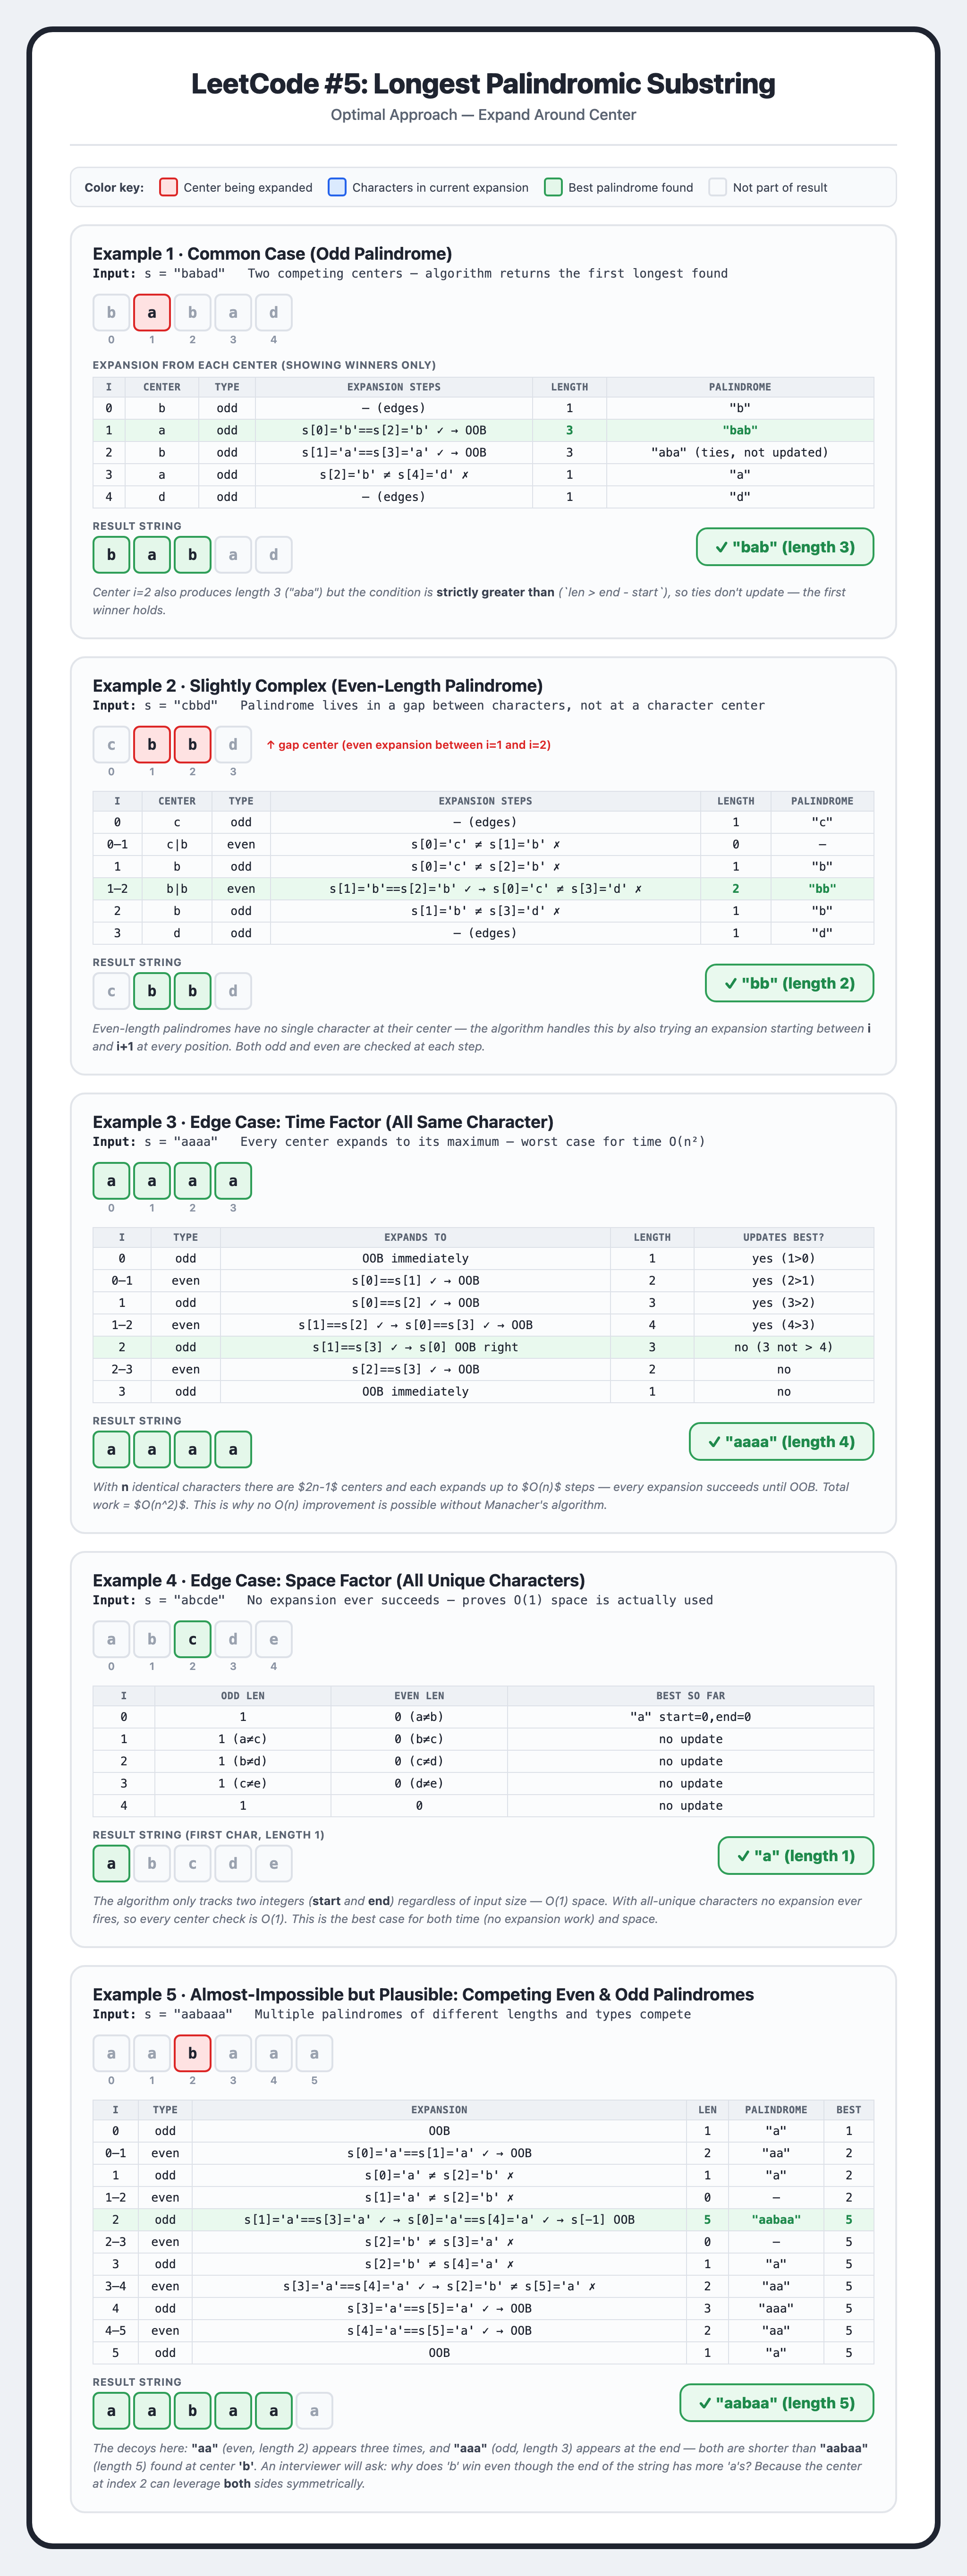